In [13]:
from pathlib import Path
import sys
import os

PROJECT_ROOT = Path(r"C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3")

os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Pasta atual:", Path.cwd())
print("Pasta src existe?", (PROJECT_ROOT / "src").exists())
print("Python usado:", sys.executable)

import pandas as pd

from src.config import DATA_DIR, REPORTS_DIR, FIGURES_DIR, DEFAULT_SAMPLE_SIZE
from src.load_data import load_all, validate_tables, enrich_with_reference_tables, find_data_dictionary
from src.preprocessing import prepare_for_modeling, missing_value_strategy
from src.eda import (
    plot_delay_distribution, plot_airline_delays, plot_time_patterns,
    plot_airport_criticality, airport_criticality, route_summary,
    cancellation_summary, delay_cause_summary
)
from src.supervised_modeling import (
    train_and_evaluate, plot_confusion_and_roc,
    random_forest_feature_importance, plot_feature_importance
)
from src.unsupervised_modeling import (
    aggregate_airports_for_clustering, elbow_silhouette, plot_elbow,
    run_kmeans, plot_clusters, describe_clusters
)
from src.utils import ensure_directories, save_dataframe

ensure_directories()
pd.set_option("display.max_columns", 80)

Pasta atual: C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3
Pasta src existe? True
Python usado: c:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\.venv\Scripts\python.exe


In [14]:
SAMPLE_SIZE = 50000

airlines, airports, flights = load_all(nrows=SAMPLE_SIZE)

print("airlines:", airlines.shape)
print("airports:", airports.shape)
print("flights:", flights.shape)
print("dicionários encontrados:", find_data_dictionary())

airlines: (14, 2)
airports: (322, 7)
flights: (50000, 31)
dicionários encontrados: [WindowsPath('C:/Users/julio/OneDrive/Documentos/Tech Challenge - Fase 3/data/dicionario_dados_flights (1).pdf')]


In [15]:
validation = validate_tables(airlines, airports, flights)

print("Duplicidades airlines:", validation["airlines_duplicates"])
print("Duplicidades airports:", validation["airports_duplicates"])
print("Duplicidades flights:", validation["flights_duplicates"])
print("Taxa de cancelamento:", validation.get("cancelled_rate"))
print("Taxa de desvio:", validation.get("diverted_rate"))

display(validation["flights_missing"].sort_values("missing_pct", ascending=False).head(20))
display(validation.get("arrival_delay_description"))

Duplicidades airlines: 0
Duplicidades airports: 0
Duplicidades flights: 0
Taxa de cancelamento: 0.02276
Taxa de desvio: 0.00218


,column,dtype,missing,missing_pct,unique_values
25,CANCELLATION_REASON,str,48862,97.724,3
29,LATE_AIRCRAFT_DELAY,float64,34592,69.184,274
30,WEATHER_DELAY,float64,34592,69.184,142
28,AIRLINE_DELAY,float64,34592,69.184,295
26,AIR_SYSTEM_DELAY,float64,34592,69.184,174
27,SECURITY_DELAY,float64,34592,69.184,37
15,ELAPSED_TIME,float64,1247,2.494,485
16,AIR_TIME,float64,1247,2.494,463
22,ARRIVAL_DELAY,float64,1247,2.494,423
18,WHEELS_ON,float64,1161,2.322,1383


count    48753.000000
mean        13.596579
std         43.375000
min        -54.000000
1%         -30.000000
5%         -21.000000
25%         -9.000000
50%          2.000000
75%         22.000000
95%         86.000000
99%        178.000000
max       1384.000000
Name: ARRIVAL_DELAY, dtype: float64

In [16]:
enriched = enrich_with_reference_tables(flights, airlines, airports)

print("Antes do merge:", flights.shape)
print("Depois do merge:", enriched.shape)

modeling = prepare_for_modeling(enriched)

print("Base modelável:", modeling.shape)
print("Proporção de atrasos > 15 min:", modeling["IS_DELAYED"].mean())

display(modeling.head())

Antes do merge: (50000, 31)
Depois do merge: (50000, 44)


Base modelável: (48753, 51)
Proporção de atrasos > 15 min: 0.3050273829302812


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,AIRLINE_NAME,ORIGIN_AIRPORT_NAME,ORIGIN_CITY,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE,ROUTE,SCHEDULED_DEPARTURE_MINUTES,SCHEDULED_ARRIVAL_MINUTES,DEPARTURE_PERIOD,DISTANCE_CATEGORY,IS_DELAYED,IS_BUSY_ROUTE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,ANC-SEA,5.0,270.0,madrugada,media,0,sim
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559,LAX-PBI,10.0,470.0,madrugada,longa,0,nao
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,US Airways Inc.,San Francisco International Airport,San Francisco,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313,SFO-CLT,20.0,486.0,madrugada,longa,0,sim
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,American Airlines Inc.,Los Angeles International Airport,Los Angeles,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056,LAX-MIA,20.0,485.0,madrugada,longa,0,sim
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,Alaska Airlines Inc.,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619,SEA-ANC,25.0,200.0,madrugada,media,0,sim


C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\outputs\figures\distribuicao_atraso_chegada.png


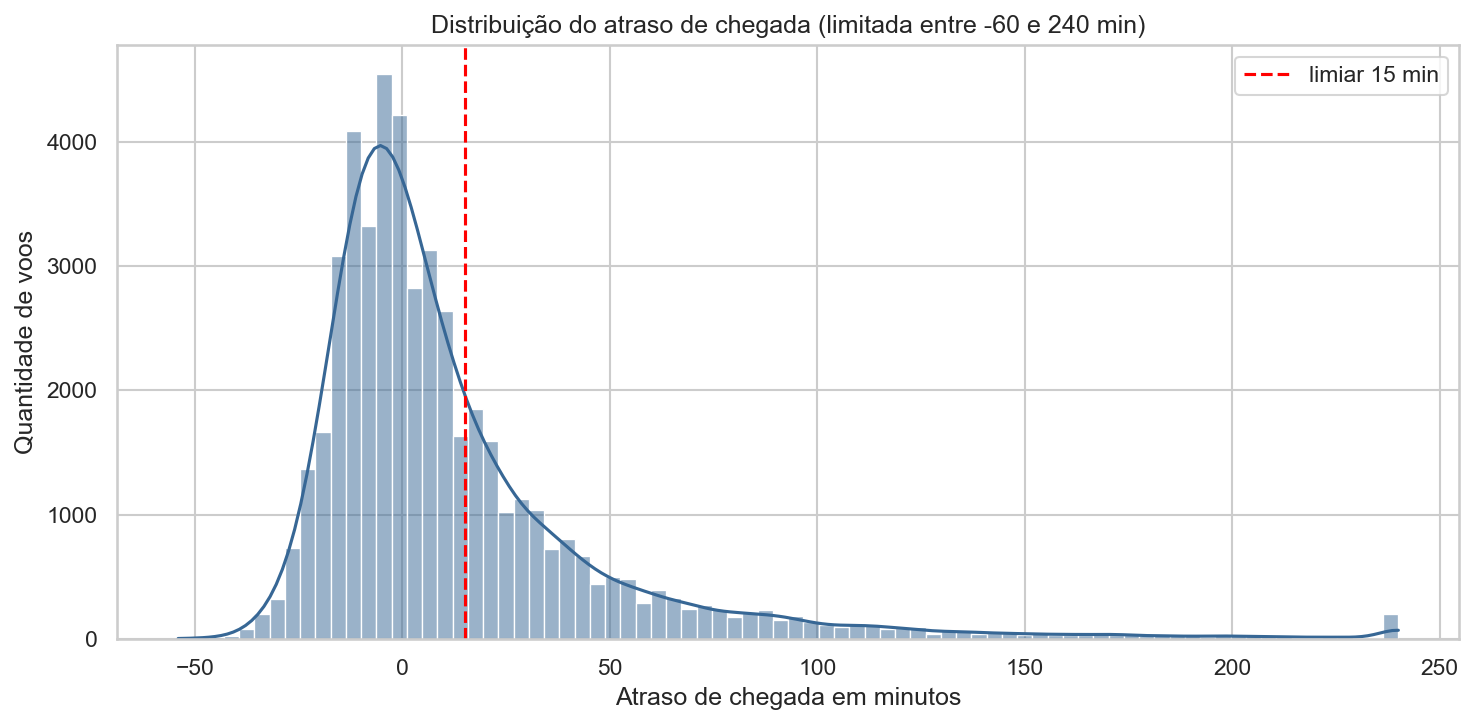

C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\outputs\figures\atraso_medio_companhia.png


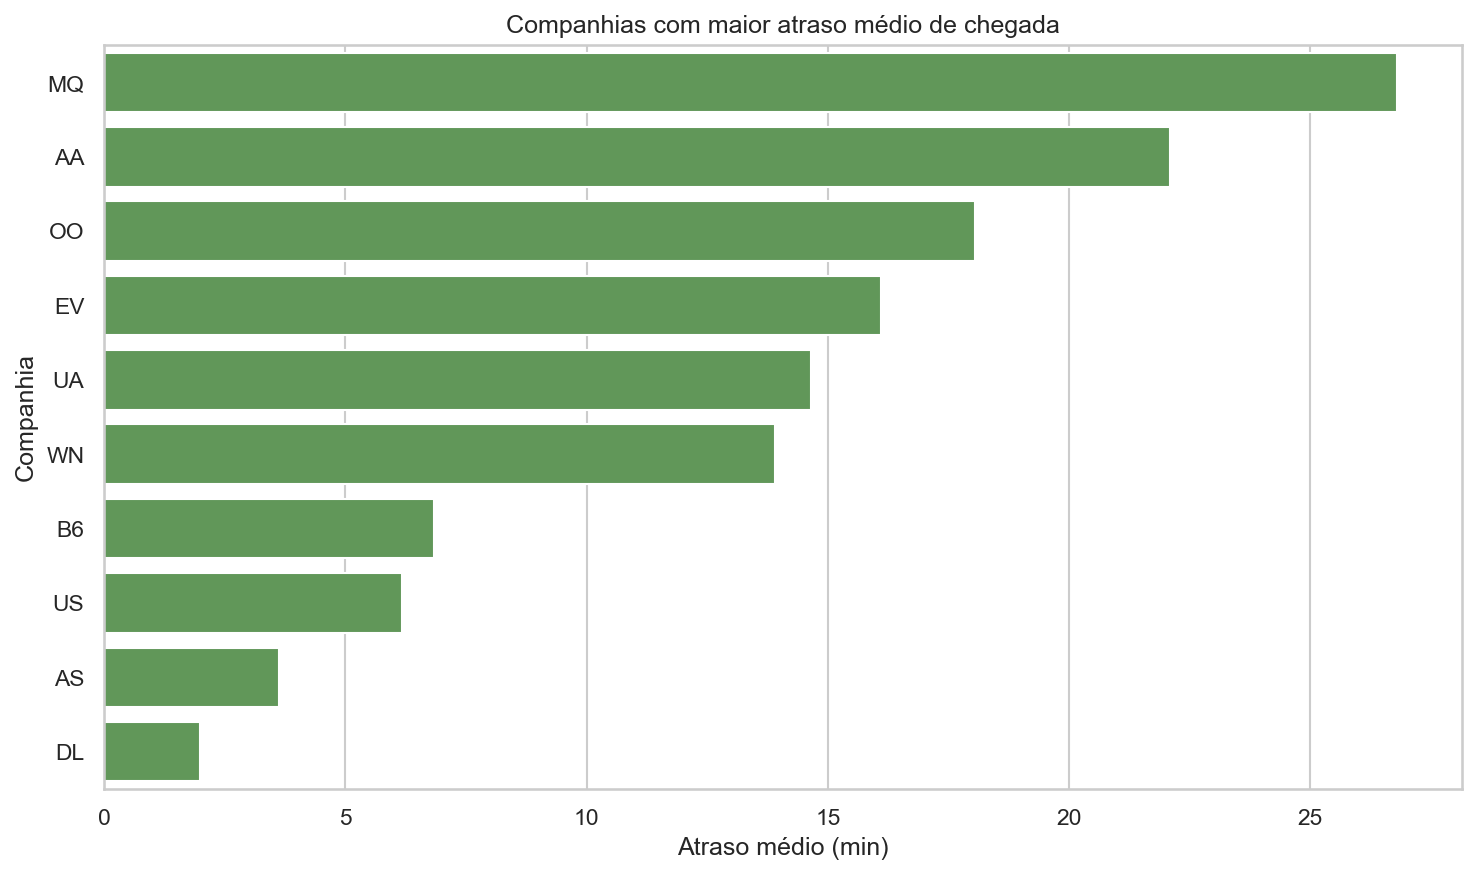

C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\outputs\figures\atraso_por_mes.png


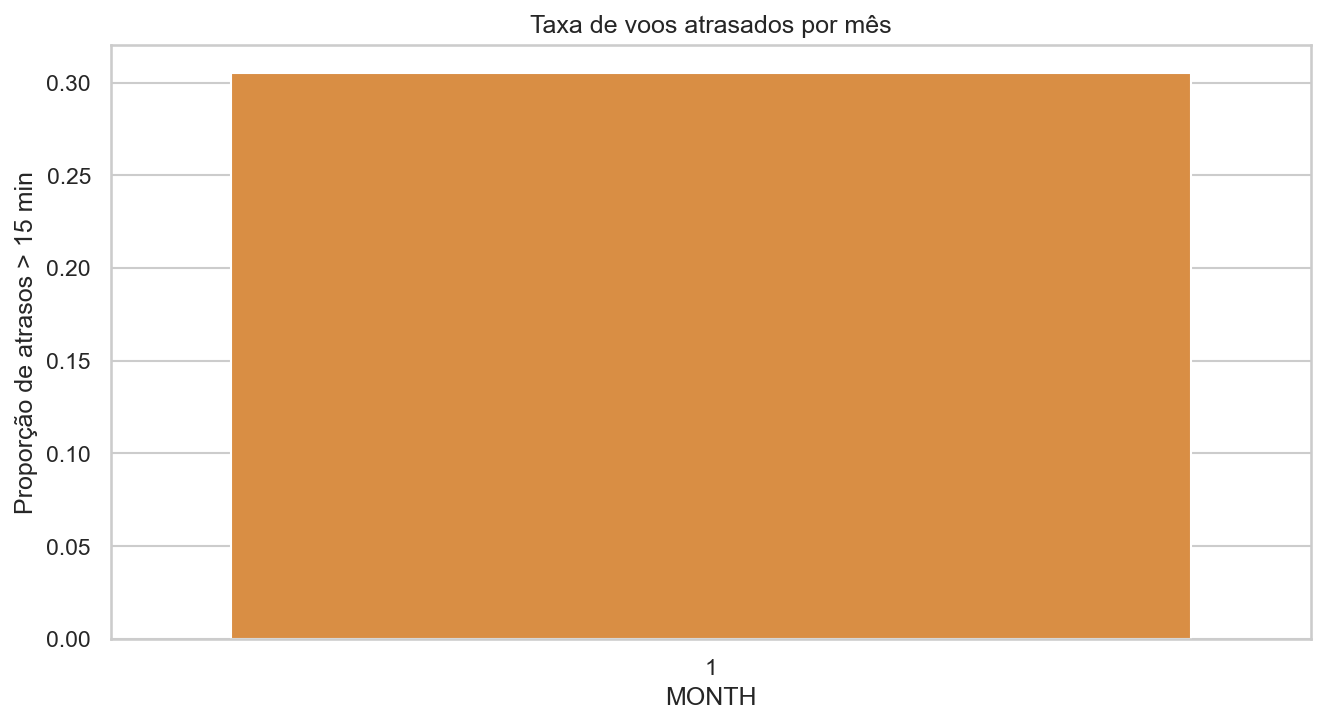

C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\outputs\figures\atraso_por_dia_semana.png


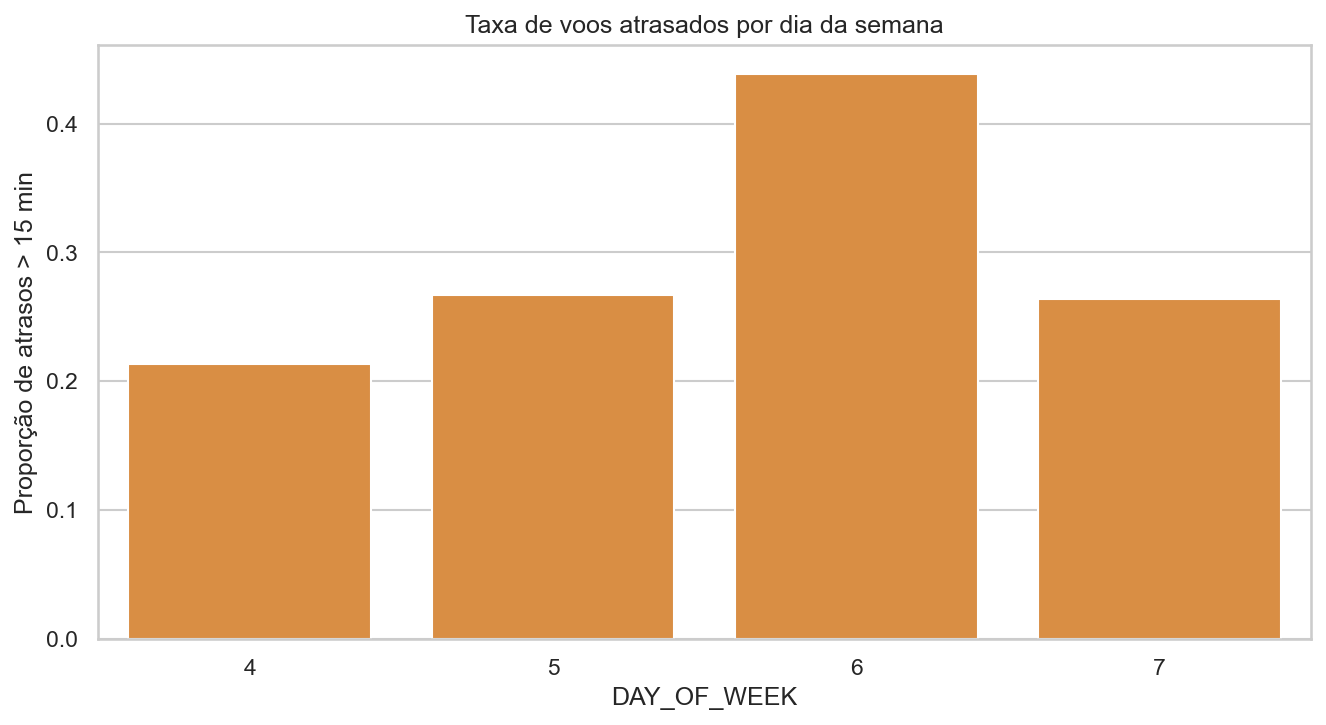

C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\outputs\figures\atraso_por_periodo_dia.png


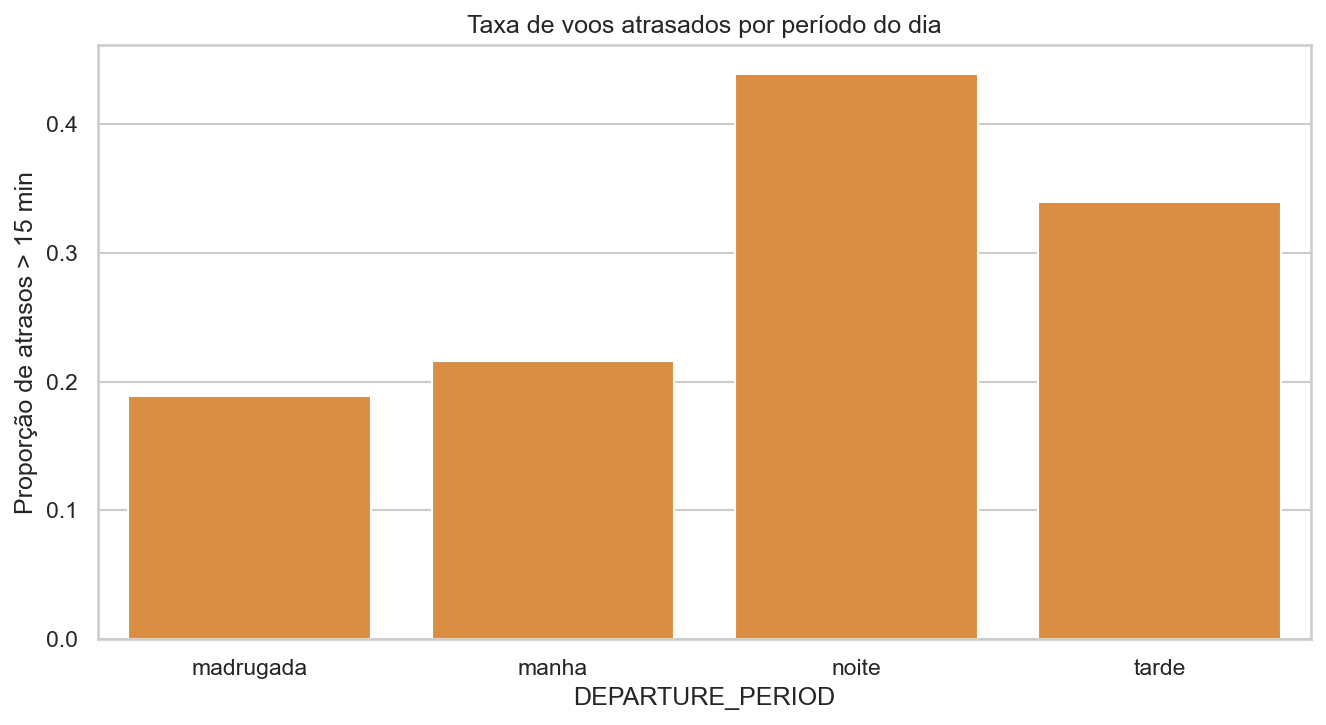

C:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\outputs\figures\aeroportos_criticos.png


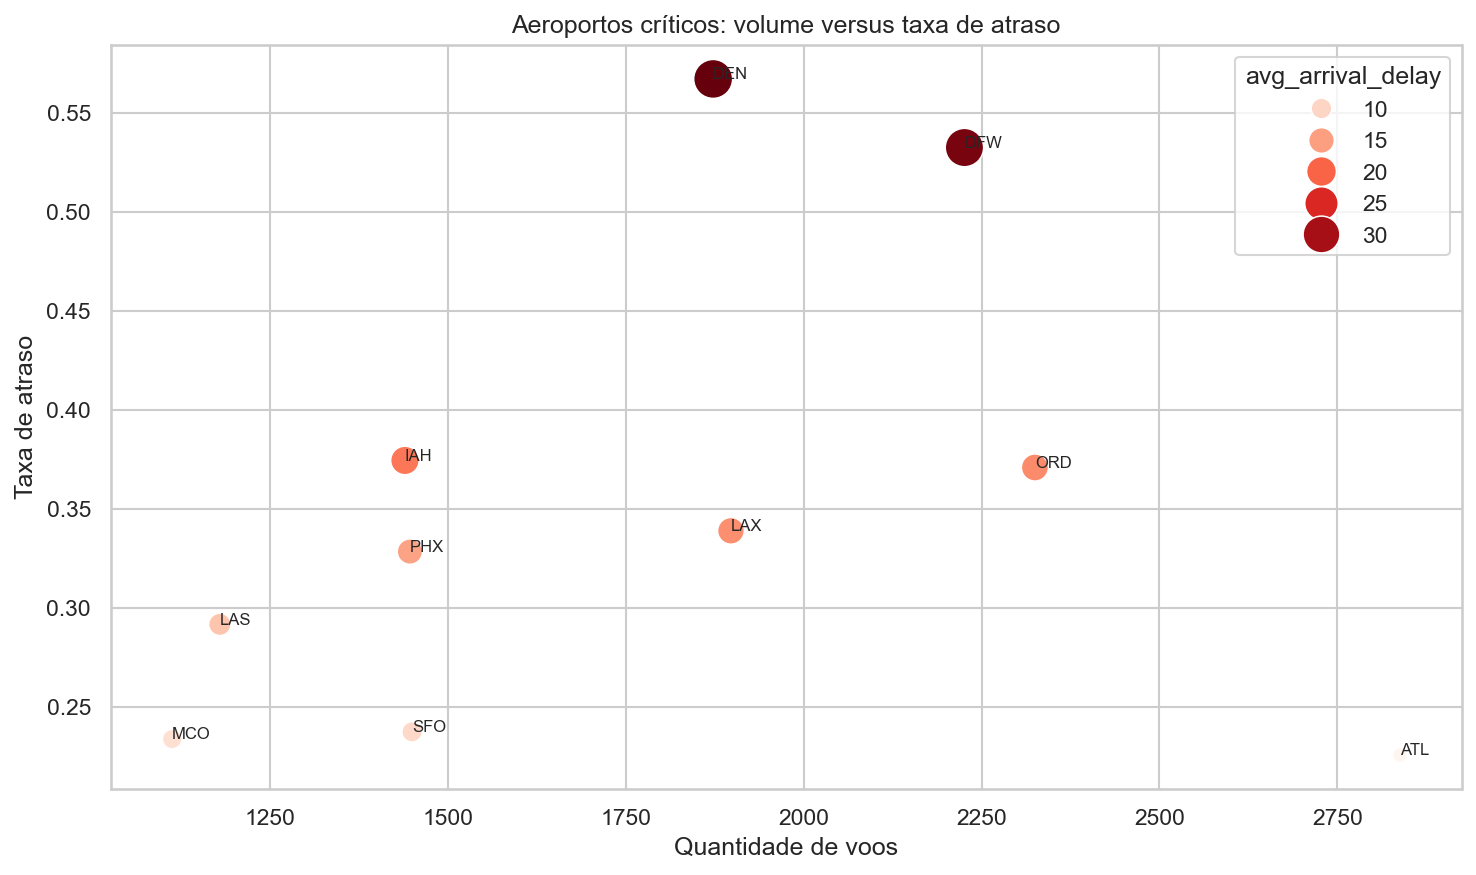

,ORIGIN_AIRPORT,flights,avg_arrival_delay,delayed_rate,destinations,criticality_score
82,DFW,2226,32.607817,0.532345,146,0.72
219,ORD,2325,16.665376,0.370753,153,0.63
81,DEN,1873,33.544047,0.567005,136,0.60
168,LAX,1898,16.231823,0.338778,78,0.42
144,IAH,1440,18.384028,0.374306,110,0.24
230,PHX,1447,14.689703,0.328265,77,0.20
269,SFO,1450,9.711034,0.237241,75,0.15
18,ATL,2838,5.490134,0.225511,164,0.10
166,LAS,1180,11.548305,0.291525,72,0.08
185,MCO,1113,9.025157,0.233603,70,0.02


,ROUTE,flights,avg_arrival_delay,delayed_rate,avg_distance


,reason,flights
0,B,551
1,A,380
2,C,207


,cause,avg_minutes
0,LATE_AIRCRAFT_DELAY,22.047832
1,AIRLINE_DELAY,18.305945
2,AIR_SYSTEM_DELAY,12.036020
3,WEATHER_DELAY,1.937046
4,SECURITY_DELAY,0.100078


In [21]:
from IPython.display import Image, display

fig_paths = []

fig_paths.append(plot_delay_distribution(modeling))
fig_paths.append(plot_airline_delays(modeling))
fig_paths.extend(plot_time_patterns(modeling))
fig_paths.append(plot_airport_criticality(modeling))

for path in fig_paths:
    print(path)
    display(Image(filename=str(path)))

display(airport_criticality(modeling).head(15))
display(route_summary(modeling).head(15))
display(cancellation_summary(enriched))
display(delay_cause_summary(enriched))

In [18]:
metrics, models, split = train_and_evaluate(modeling, save_models=True)

display(metrics)

save_dataframe(metrics, REPORTS_DIR / "supervised_metrics.csv")

c:\Users\julio\OneDrive\Documentos\Tech Challenge - Fase 3\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,accuracy,precision,recall,f1,roc_auc
2,random_forest,0.709246,0.518864,0.643626,0.574550,0.759023
1,logistic_regression,0.685044,0.488591,0.696880,0.574437,0.752420
0,baseline_majority,0.694971,0.000000,0.000000,0.000000,0.500000


In [19]:
X_train, X_test, y_train, y_test = split

best_model_name = metrics.iloc[0]["model"]

if best_model_name == "baseline_majority":
    best_model_name = "random_forest"

plot_confusion_and_roc(models[best_model_name], X_test, y_test, str(best_model_name))

importance = random_forest_feature_importance(models["random_forest"])
display(importance)

plot_feature_importance(importance)

,feature,importance
1,num__DAY,0.126668
4,num__SCHEDULED_ARRIVAL_MINUTES,0.112630
2,num__DAY_OF_WEEK,0.104674
3,num__SCHEDULED_DEPARTURE_MINUTES,0.093699
328,cat__DEPARTURE_PERIOD_manha,0.066651
10,cat__AIRLINE_DL,0.047348
329,cat__DEPARTURE_PERIOD_noite,0.038337
57,cat__ORIGIN_AIRPORT_DFW,0.033561
56,cat__ORIGIN_AIRPORT_DEN,0.032095
14,cat__AIRLINE_MQ,0.029987


WindowsPath('C:/Users/julio/OneDrive/Documentos/Tech Challenge - Fase 3/outputs/figures/importancia_variaveis_random_forest.png')

In [20]:
airport_features = aggregate_airports_for_clustering(modeling)

display(airport_features.head())

cluster_metrics = elbow_silhouette(airport_features)
display(cluster_metrics)

plot_elbow(cluster_metrics)

chosen_k = int(cluster_metrics.sort_values("silhouette", ascending=False).iloc[0]["k"]) if not cluster_metrics.empty else 4

clustered, kmeans, scaler, pca, silhouette = run_kmeans(airport_features, k=chosen_k)

print("k escolhido:", chosen_k)
print("silhouette:", silhouette)

plot_clusters(clustered)

cluster_profiles = describe_clusters(clustered)
display(cluster_profiles)

save_dataframe(clustered, REPORTS_DIR / "airport_clusters.csv")
save_dataframe(cluster_profiles, REPORTS_DIR / "cluster_profiles.csv")

,ORIGIN_AIRPORT,total_flights,avg_arrival_delay,delayed_rate,avg_distance,cancelled_rate,destinations_served,madrugada,morning_delay_rate,night_delay_rate,afternoon_delay_rate
0,ABE,15,-2.533333,0.200000,580.133333,0.0,3,0.0,0.100000,0.00,0.400000
1,ABI,13,33.153846,0.538462,158.000000,0.0,1,0.0,0.571429,0.00,0.750000
2,ABQ,192,25.447917,0.442708,732.651042,0.0,21,0.0,0.337079,0.75,0.453333
3,ABR,7,-8.571429,0.000000,257.000000,0.0,1,0.0,0.000000,0.00,0.000000
4,ABY,6,-0.166667,0.166667,145.000000,0.0,1,0.0,0.000000,0.00,0.333333


,k,inertia,silhouette
0,2,1933.755440,0.231581
1,3,1468.643436,0.270468
2,4,1230.927580,0.247560
3,5,1069.660119,0.259315
4,6,944.904328,0.265626
5,7,854.980375,0.273160
6,8,766.197744,0.269067


k escolhido: 7
silhouette: 0.2731597633194638


,cluster,total_flights,avg_arrival_delay,delayed_rate,avg_distance,cancelled_rate,destinations_served,morning_delay_rate,afternoon_delay_rate,night_delay_rate
0,0,17.266,-0.680,0.116,372.444,0.0,2.519,0.093,0.114,0.061
1,1,42.167,28.591,0.454,401.521,0.0,5.292,0.333,0.466,0.788
2,2,2140.400,21.338,0.414,793.358,0.0,141.800,0.313,0.418,0.562
3,3,164.600,12.180,0.266,862.370,0.0,15.840,0.171,0.284,0.382
4,4,15.133,55.551,0.820,441.707,0.0,2.867,0.828,0.720,0.142
5,5,23.426,18.398,0.382,376.510,0.0,3.206,0.309,0.464,0.029
6,6,931.727,9.703,0.259,1000.497,0.0,64.545,0.181,0.287,0.375
